In [1]:
import torch 
import matplotlib.pyplot as plt
import numpy as np 
import seaborn as sns
import os
outdir = r"C:\Document\Serieux\Travail\python_work\cEBNM_torch\notebooks\cEBMF_test\hierarchical_factor_model"
os.makedirs(outdir, exist_ok=True)
# Reproducibility


In [2]:
#torch.manual_seed(1)
N = 2000  
P= 200
# Scatter of x vs y 
torch.manual_seed(1)

# -------------------------
# 2) Generate f (3 x 200)
#    f[0,i] ~ t1_i * N(0,1), f[1,i], f[2,i] ~ t2_i * N(0,1)
# -------------------------

t0 = torch.randint(0, 2, (P,), dtype=torch.float32)  # 0/1
t1 = torch.randint(0, 2, (P,), dtype=torch.float32)  # 0/1
t2 = torch.randint(0, 2, (P,), dtype=torch.float32)  # 0/1
t11 = torch.randint(0, 2, (P,), dtype=torch.float32)  # 0/1
t12 = torch.randint(0, 2, (P,), dtype=torch.float32)  # 0/1
t21 = torch.randint(0, 2, (P,), dtype=torch.float32)  # 0/1
t22 = torch.randint(0, 2, (P,), dtype=torch.float32)  # 0/1

a0 = t0 * torch.randn(P)
b1 = t1 * torch.randn(P)
b2 = t2 * torch.randn(P)
detla11= t11 *torch.randn(P)

detla12= t11 *torch.randn(P)
detla21= t11 *torch.randn(P)
detla22= t11 *torch.randn(P)  
f_mat = torch.stack([a0,b1,b2, detla11, detla12,detla21, detla22 ], dim=0)
f_mat

tensor([[ 0.8993,  0.4417, -0.0000,  ...,  0.6032, -1.8230, -0.0000],
        [-0.0000, -0.0000,  0.0000,  ...,  0.0000, -0.5855,  1.6023],
        [-0.0000,  0.0000, -0.2332,  ...,  0.0000,  0.0000,  0.0000],
        ...,
        [-0.0000,  0.0000,  0.0000,  ...,  1.2064,  0.0000,  0.0781],
        [-0.0000,  0.0000, -0.0000,  ...,  0.0251, -0.0000, -0.7000],
        [-0.0000,  0.0000, -0.0000,  ...,  0.0824, -0.0000,  1.9809]])

In [3]:

N= 1000

L = torch.zeros(N, 7, dtype=torch.float32)


L[:,0]=1
L[0:500, 1]=1

L [500:,2]=1
L[0:250,3]=1
L[251:500,4]=1

L[501:750,5]=1

L[751:,6]=1

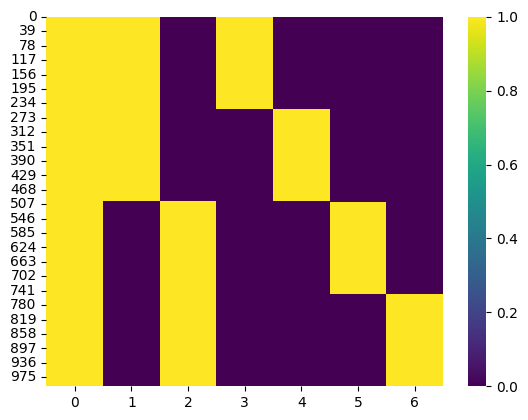

In [4]:


sns.heatmap(L , cmap="viridis", annot=False)  # set annot=True for numbers
plt.show()


In [5]:
L.shape

torch.Size([1000, 7])

In [6]:
L 

tensor([[1., 1., 0.,  ..., 0., 0., 0.],
        [1., 1., 0.,  ..., 0., 0., 0.],
        [1., 1., 0.,  ..., 0., 0., 0.],
        ...,
        [1., 0., 1.,  ..., 0., 0., 1.],
        [1., 0., 1.,  ..., 0., 0., 1.],
        [1., 0., 1.,  ..., 0., 0., 1.]])

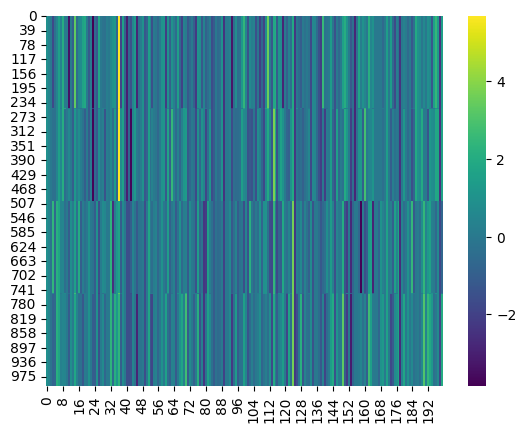

In [7]:
X_true= L@f_mat 
Z = L@f_mat + 0.5*torch.randn(N, P)  * 2.5  # (N, M)
Z_np = Z.detach().cpu().numpy()

# Save as tab-delimited text
np.savetxt(os.path.join(outdir, "Z_matrix.txt"), Z_np, fmt="%.6f", delimiter="\t")

X_true=    L@f_mat 
X_np = X_true.detach().cpu().numpy()

# Save as tab-delimited text
np.savetxt(os.path.join(outdir, "Z_matrix.txt"), Z_np, fmt="%.6f", delimiter="\t")
np.savetxt(os.path.join(outdir, "X_matrix.txt"), X_np, fmt="%.6f", delimiter="\t")
sns.heatmap(X_true , cmap="viridis", annot=False)  # set annot=True for numbers
plt.show()

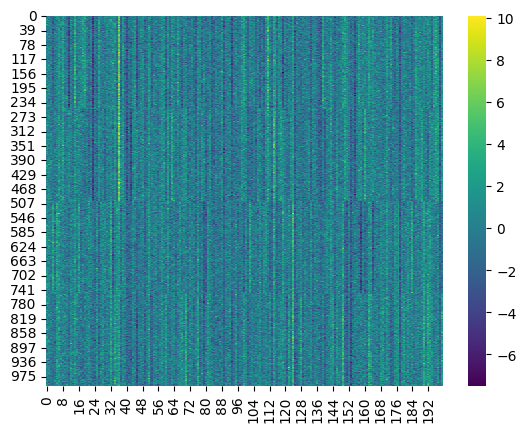

In [8]:
sns.heatmap(Z , cmap="viridis", annot=False)  # set annot=True for numbers
plt.show()

In [9]:
from cebmf_torch import cEBMF

In [ ]:
mycebmf01=  cEBMF(data=Z, 
                 prior_L="gbinary", K=10,
                  allow_backfitting=False ) 
mycebmf01.initialise_factors()
  
mycebmf01.fit(20)

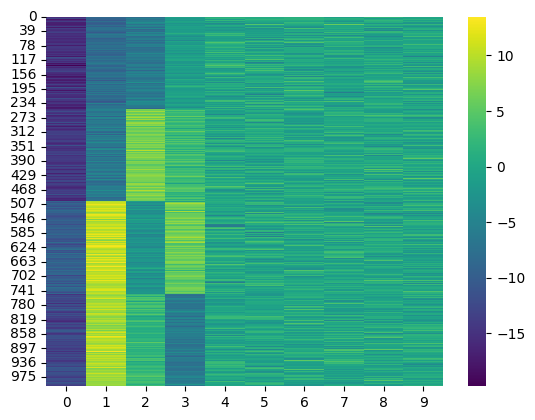

In [11]:
sns.heatmap(mycebmf01.L , cmap="viridis", annot=False)  # set annot=True for numbers
plt.show()

In [16]:
 
mycebmf1=  cEBMF(data=Z,self_row_cov=True,
                 prior_L="cgb_sharp", K=10,
                  allow_backfitting=False ) 
mycebmf1.initialise_factors()
 
  
mycebmf1.fit(3)

[CGB] Epoch 10/10, Loss=40.4998, mu2=-0.080, sigma2=0.932
[CGB] Epoch 10/10, Loss=23.0156, mu2=0.069, sigma2=0.618
[CGB] Epoch 10/10, Loss=9.2785, mu2=0.019, sigma2=0.445
[CGB] Epoch 10/10, Loss=8.7005, mu2=0.053, sigma2=0.416
[CGB] Epoch 10/10, Loss=2.2256, mu2=-0.008, sigma2=0.078
[CGB] Epoch 10/10, Loss=2.1912, mu2=0.007, sigma2=0.104
[CGB] Epoch 10/10, Loss=2.1786, mu2=-0.007, sigma2=0.102
[CGB] Epoch 10/10, Loss=2.1493, mu2=0.004, sigma2=0.068
[CGB] Epoch 10/10, Loss=2.1448, mu2=0.006, sigma2=0.122
[CGB] Epoch 10/10, Loss=2.1292, mu2=0.000, sigma2=0.087
[CGB] Epoch 10/10, Loss=34.7631, mu2=-0.160, sigma2=0.348
[CGB] Epoch 10/10, Loss=18.3457, mu2=0.148, sigma2=0.145
[CGB] Epoch 10/10, Loss=5.7534, mu2=0.097, sigma2=0.070
[CGB] Epoch 10/10, Loss=5.1085, mu2=0.136, sigma2=0.060
[CGB] Epoch 10/10, Loss=2.0371, mu2=0.002, sigma2=0.000
[CGB] Epoch 10/10, Loss=2.5979, mu2=-0.000, sigma2=0.000
[CGB] Epoch 10/10, Loss=2.3873, mu2=0.002, sigma2=0.000
[CGB] Epoch 10/10, Loss=2.2575, mu2=0.0

CEBMFResult(L=tensor([[-7.2810e-01,  0.0000e+00,  0.0000e+00,  ...,  1.8060e-10,
         -3.0944e-10,  1.4224e-13],
        [-7.1770e-01,  0.0000e+00,  1.9936e-05,  ...,  1.6998e-10,
         -2.6523e-10,  4.7374e-13],
        [-7.4297e-01,  0.0000e+00,  0.0000e+00,  ...,  2.1247e-11,
         -1.1051e-10,  2.3652e-13],
        ...,
        [-6.8702e-01,  2.7520e-01,  9.8746e-09,  ...,  1.6891e-09,
          0.0000e+00,  0.0000e+00],
        [-6.0657e-01,  2.7980e-01,  0.0000e+00,  ...,  2.3372e-10,
         -2.6523e-10,  4.7181e-13],
        [-6.6673e-01,  2.8478e-01,  0.0000e+00,  ...,  0.0000e+00,
          0.0000e+00,  1.8389e-12]]), F=tensor([[-1.0750e+00,  1.1914e+00,  5.3144e-01,  ..., -2.7943e-02,
          4.2699e-03, -2.3336e-04],
        [-6.3045e-01,  4.3559e-02,  2.2835e-01,  ...,  1.3380e-02,
          5.6099e-04,  2.7101e-04],
        [ 8.4198e-02, -6.1014e-01,  1.6656e-02,  ..., -1.1773e-02,
          6.8362e-04,  2.0038e-04],
        ...,
        [-1.7534e+00, -1.0614

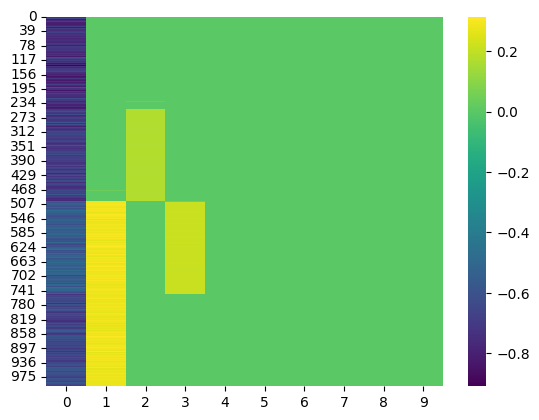

In [17]:
sns.heatmap(mycebmf1.L , cmap="viridis", annot=False)  # set annot=True for numbers
plt.show()

In [15]:
mycebmf21=  cEBMF(data=Z,self_row_cov=True,
                 prior_L="cgb_sharp_2",
                  K=10,
                  allow_backfitting=False) 
mycebmf21.initialise_factors(L= mycebmf1.L, F=mycebmf1.F)
 
  
mycebmf21.fit(10)

[CGB-2] Epoch 10/10, Loss=50.2242, mu_pos=0.673, mu_neg=-0.734, sigma1=0.323, sigma2=0.397
[CGB-2] Epoch 10/10, Loss=22.5672, mu_pos=0.734, mu_neg=-0.734, sigma1=0.292, sigma2=0.213
[CGB-2] Epoch 10/10, Loss=8.4127, mu_pos=0.733, mu_neg=-0.733, sigma1=0.175, sigma2=0.178
[CGB-2] Epoch 10/10, Loss=7.8856, mu_pos=0.733, mu_neg=-0.733, sigma1=0.147, sigma2=0.166
[CGB-2] Epoch 10/10, Loss=2.3985, mu_pos=0.718, mu_neg=-0.720, sigma1=0.040, sigma2=0.115
[CGB-2] Epoch 10/10, Loss=2.4633, mu_pos=0.721, mu_neg=-0.721, sigma1=0.084, sigma2=0.044
[CGB-2] Epoch 10/10, Loss=2.4510, mu_pos=0.717, mu_neg=-0.716, sigma1=0.063, sigma2=0.042
[CGB-2] Epoch 10/10, Loss=2.4451, mu_pos=0.718, mu_neg=-0.717, sigma1=0.068, sigma2=0.038
[CGB-2] Epoch 10/10, Loss=2.4850, mu_pos=0.719, mu_neg=-0.719, sigma1=0.073, sigma2=0.050
[CGB-2] Epoch 10/10, Loss=2.4397, mu_pos=0.719, mu_neg=-0.718, sigma1=0.084, sigma2=0.056
[CGB-2] Epoch 10/10, Loss=20.3145, mu_pos=0.673, mu_neg=-0.776, sigma1=0.000, sigma2=0.039
[CGB-2]

CEBMFResult(L=tensor([[-8.0689e-01, -7.6918e-01, -8.0313e-01,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        [-8.0689e-01, -7.6918e-01, -8.0017e-01,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        [-8.0689e-01, -7.6918e-01, -8.0313e-01,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        ...,
        [-8.0689e-01,  7.7658e-01,  1.8186e-12,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        [-8.0689e-01,  7.7658e-01,  3.7043e-13,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        [-8.0689e-01,  7.7658e-01, -2.2402e-13,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00]]), F=tensor([[-1.0693e+00,  1.6615e-01,  1.9869e-01,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        [-5.5194e-01, -6.4012e-03,  1.2058e-02,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        [ 1.6242e-01, -1.0480e-01, -3.4367e-04,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        ...,
        [-1.4432e+00, -5.3182

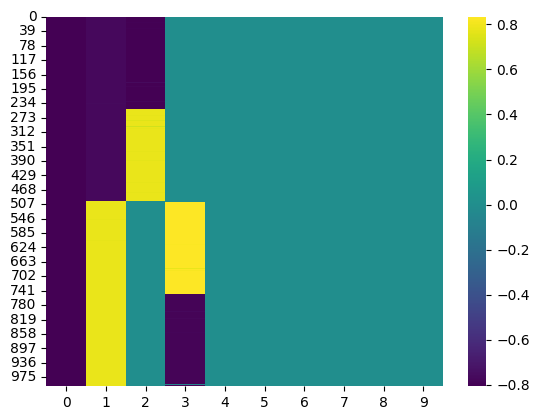

In [16]:
sns.heatmap(mycebmf21.L , cmap="viridis", annot=False)  # set annot=True for numbers
plt.show()

In [17]:
mycebmf0=  cEBMF(data=Z ,K=10 ) 
mycebmf0.initialise_factors()
mycebmf0.fit(20)

CEBMFResult(L=tensor([[-14.6432,  -8.5592,  -7.8449,  ...,   0.0000,   0.0000,   0.0000],
        [-14.4401,  -8.6061,  -4.8383,  ...,   0.0000,   0.0000,   0.0000],
        [-14.8648,  -8.1610,  -8.3798,  ...,   0.0000,   0.0000,   0.0000],
        ...,
        [-12.8027,   9.1314,   2.1037,  ...,   0.0000,   0.0000,   0.0000],
        [-10.7544,  10.0296,   0.9644,  ...,   0.0000,   0.0000,   0.0000],
        [-12.4057,  10.5523,   0.3727,  ...,   0.0000,   0.0000,   0.0000]]), F=tensor([[-6.2307e-02,  2.6313e-02,  1.8635e-02,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        [-3.2737e-02,  9.7870e-04,  1.5961e-03,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        [ 8.5727e-03, -1.1889e-02, -1.5403e-04,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        ...,
        [-8.9937e-02, -2.9376e-02,  2.6721e-02,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        [ 1.6103e-01,  2.4437e-04, -1.9665e-04,  ...,  0.0000e+00,
          0.0000e+00,

In [18]:
 
mycebmf2=  cEBMF(data=Z,self_row_cov=True,
                 prior_L="cgb_sharp", K=10,
                  allow_backfitting=False ) 
mycebmf2.initialise_factors()
 
mycebmf2.fit(10)

[CGB] Epoch 10/10, Loss=40.5128, mu2=-0.080, sigma2=0.942
[CGB] Epoch 10/10, Loss=22.9930, mu2=0.066, sigma2=0.601
[CGB] Epoch 10/10, Loss=9.2431, mu2=0.017, sigma2=0.441
[CGB] Epoch 10/10, Loss=8.7156, mu2=0.042, sigma2=0.398
[CGB] Epoch 10/10, Loss=2.2262, mu2=-0.009, sigma2=0.100
[CGB] Epoch 10/10, Loss=2.1949, mu2=0.012, sigma2=0.084
[CGB] Epoch 10/10, Loss=2.1840, mu2=-0.008, sigma2=0.098
[CGB] Epoch 10/10, Loss=2.1529, mu2=0.006, sigma2=0.108
[CGB] Epoch 10/10, Loss=2.1413, mu2=0.002, sigma2=0.124
[CGB] Epoch 10/10, Loss=2.1309, mu2=0.003, sigma2=0.096
[CGB] Epoch 10/10, Loss=34.7474, mu2=-0.160, sigma2=0.365
[CGB] Epoch 10/10, Loss=18.2680, mu2=0.144, sigma2=0.141
[CGB] Epoch 10/10, Loss=5.7122, mu2=0.099, sigma2=0.068
[CGB] Epoch 10/10, Loss=5.0492, mu2=0.128, sigma2=0.055
[CGB] Epoch 10/10, Loss=2.2012, mu2=0.002, sigma2=0.000
[CGB] Epoch 10/10, Loss=2.4276, mu2=-0.003, sigma2=0.000
[CGB] Epoch 10/10, Loss=2.8391, mu2=0.003, sigma2=0.000
[CGB] Epoch 10/10, Loss=2.7005, mu2=-0.

CEBMFResult(L=tensor([[-0.4518,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        [-0.4518,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        [-0.4518,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        ...,
        [-0.4518,  0.3973,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        [-0.4518,  0.3973,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        [-0.4518,  0.3973,  0.0000,  ...,  0.0000,  0.0000,  0.0000]]), F=tensor([[-1.2827e+00,  1.0463e+00,  1.5205e+00,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        [-9.8202e-01, -6.5720e-03,  5.1036e-02,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        [ 5.1068e-03, -5.7750e-01, -9.2702e-03,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        ...,
        [-3.0136e+00, -1.5259e+00,  1.7774e+00,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        [ 5.2905e+00,  1.3393e+00, -9.0193e-03,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        [-3.1201e+00,

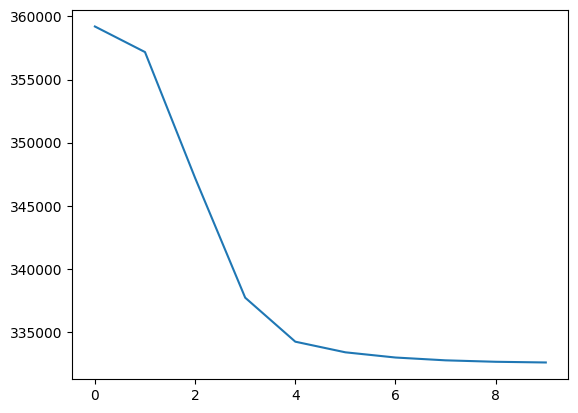

In [19]:
plt.plot(mycebmf2.obj)

In [20]:
k=0
#mycebmf2._update_factors(k)

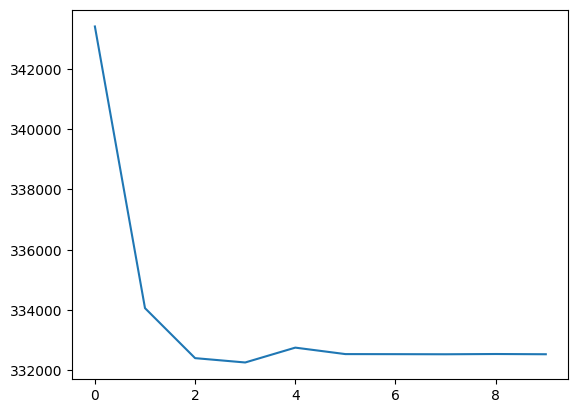

In [21]:
plt.plot(mycebmf21.obj)

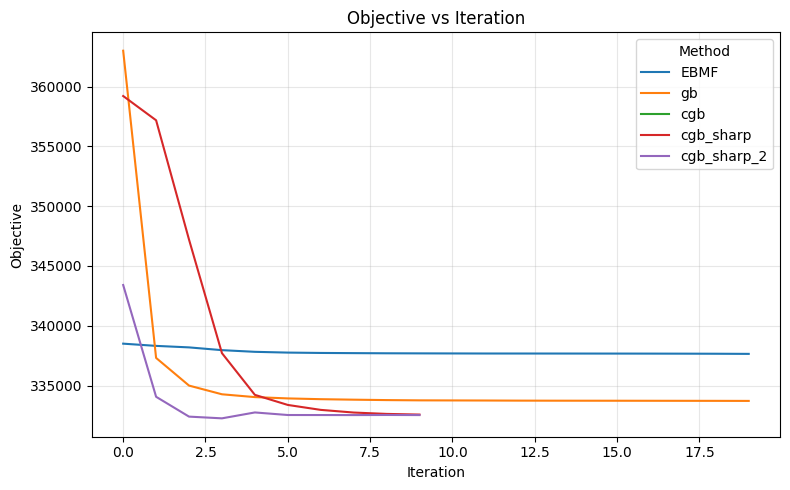

In [22]:
import matplotlib.pyplot as plt
def to1d(a):
    if isinstance(a, torch.Tensor):
        return a.detach().cpu().flatten().numpy()
    return np.asarray(a).ravel()

fig, ax = plt.subplots(figsize=(8,5))

ax.plot(to1d(mycebmf0.obj), label="EBMF")
ax.plot(to1d(mycebmf01.obj), label="gb")
ax.plot(to1d(mycebmf1.obj), label="cgb")
ax.plot(to1d(mycebmf2.obj),  label="cgb_sharp")

ax.plot(to1d(mycebmf21.obj),  label="cgb_sharp_2")

ax.set_title("Objective vs Iteration")
ax.set_xlabel("Iteration")
ax.set_ylabel("Objective")
ax.legend(title="Method", loc="best")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [23]:
mycebmf1.F

tensor([[-1.0693e+00,  1.6615e-01,  1.9869e-01,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        [-5.5194e-01, -6.4012e-03,  1.2058e-02,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        [ 1.6242e-01, -1.0480e-01, -3.4367e-04,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        ...,
        [-1.4432e+00, -5.3182e-01,  1.9751e-01,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        [ 2.6508e+00,  3.6487e-01, -4.8232e-04,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        [-1.3087e+00, -5.9704e-01,  2.8799e-01,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00]])

(array([245.,   1.,   2.,   0., 503.,   0.,   0.,   0.,   0., 249.]),
 array([-0.79160523, -0.62902528, -0.4664453 , -0.30386531, -0.14128536,
         0.02129459,  0.18387461,  0.3464545 ,  0.50903451,  0.67161453,
         0.83419436]),
 <BarContainer object of 10 artists>)

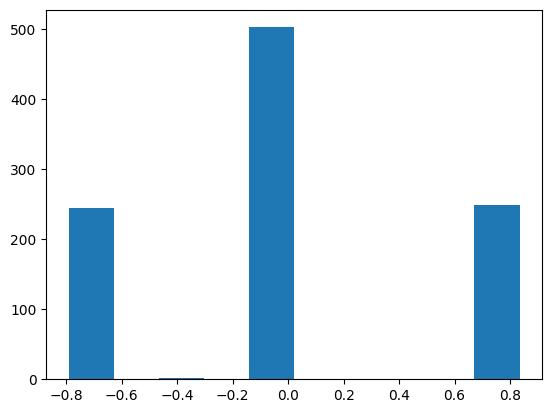

In [24]:
plt.hist(mycebmf1.L[:,3 ])


(array([245.,   1.,   2.,   0., 503.,   0.,   0.,   0.,   0., 249.]),
 array([-0.79160523, -0.62902528, -0.4664453 , -0.30386531, -0.14128536,
         0.02129459,  0.18387461,  0.3464545 ,  0.50903451,  0.67161453,
         0.83419436]),
 <BarContainer object of 10 artists>)

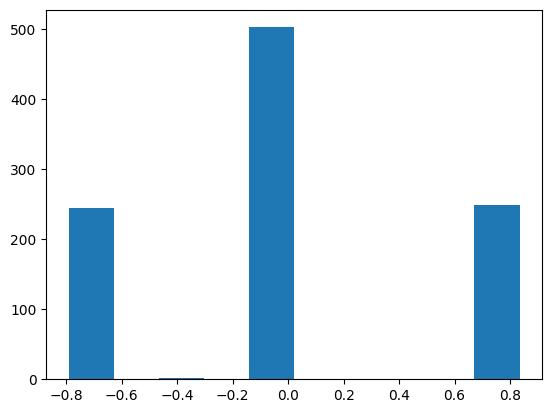

In [25]:
plt.hist(mycebmf21.L[:,3 ])

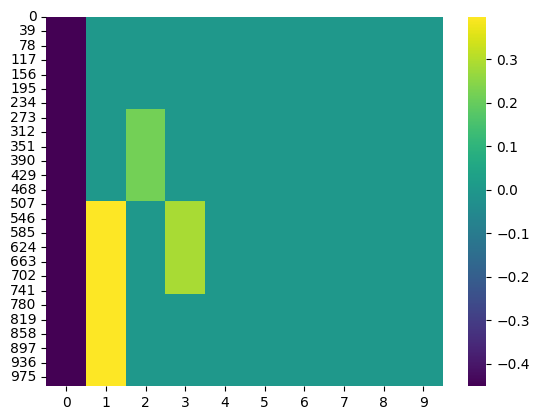

In [26]:
sns.heatmap(mycebmf2.L , cmap="viridis", annot=False)  # set annot=True for numbers
plt.show()

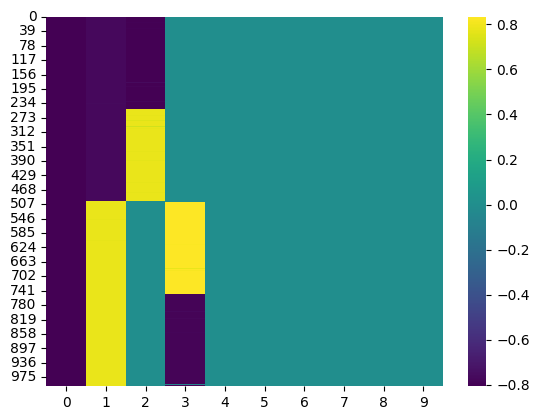

In [27]:
 
sns.heatmap(mycebmf21.L , cmap="viridis", annot=False)  # set annot=True for numbers
plt.show()

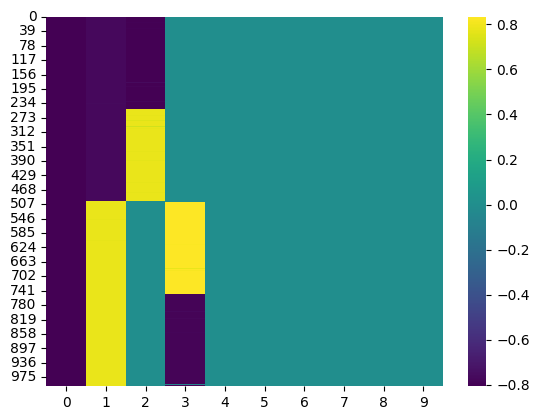

In [28]:
 
sns.heatmap(mycebmf1.L , cmap="viridis", annot=False)  # set annot=True for numbers
plt.show()

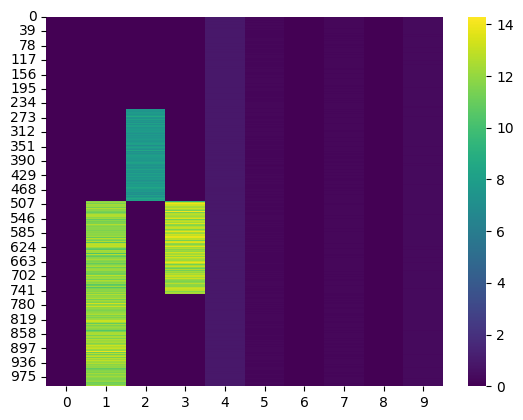

In [29]:
sns.heatmap(mycebmf01.L , cmap="viridis", annot=False)  # set annot=True for numbers
plt.show()

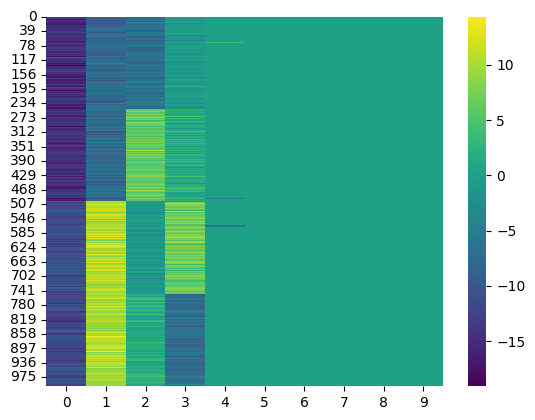

In [30]:
sns.heatmap(mycebmf0.L , cmap="viridis", annot=False)  # set annot=True for numbers
plt.show()

In [31]:
mycebmf1.L[:,4]

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 

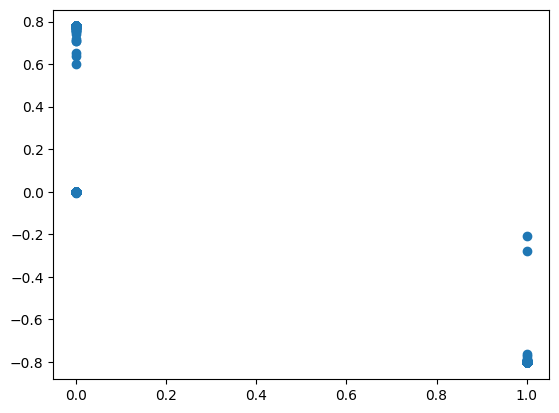

In [32]:
plt.scatter(L[:,3],mycebmf1.L[:,2])

(array([245.,   1.,   2.,   0., 503.,   0.,   0.,   0.,   0., 249.]),
 array([-0.79160523, -0.62902528, -0.4664453 , -0.30386531, -0.14128536,
         0.02129459,  0.18387461,  0.3464545 ,  0.50903451,  0.67161453,
         0.83419436]),
 <BarContainer object of 10 artists>)

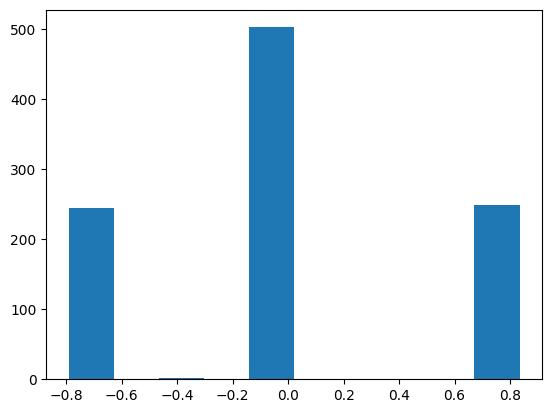

In [33]:
plt.hist(mycebmf1.L[:,3 ])

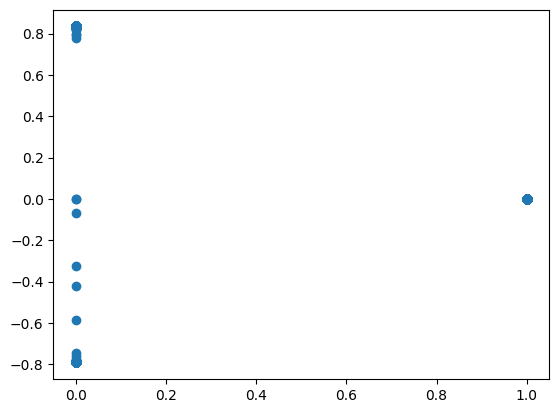

In [34]:
plt.scatter(L[:,1],mycebmf1.L[:,3])

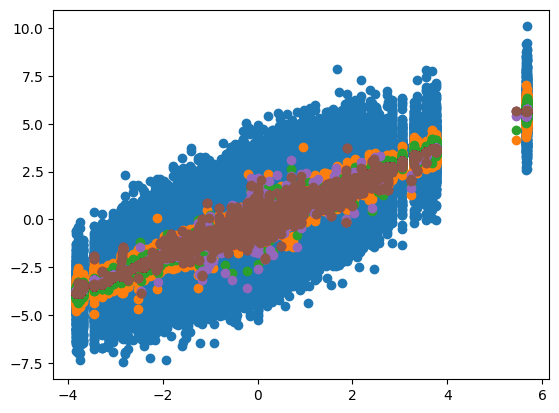

In [35]:
plt.scatter(L@f_mat,Z)
plt.scatter(L@f_mat,mycebmf0.L@mycebmf0.F.T )


plt.scatter(L@f_mat,mycebmf01.L@mycebmf01.F.T )

plt.scatter(L@f_mat,mycebmf1.L@mycebmf1.F.T )
plt.scatter(L@f_mat,mycebmf2.L@ mycebmf2.F.T )

plt.scatter(L@f_mat,mycebmf21.L@ mycebmf21.F.T ) 

In [36]:
print(torch.mean( (L@f_mat - mycebmf0.L@ mycebmf0.F.T )**2))
print(torch.mean((L@f_mat - mycebmf1.L@ mycebmf1.F.T )**2))
print(torch.mean((L@f_mat - mycebmf2.L@ mycebmf2.F.T )**2)) 
 
print(torch.mean((L@f_mat - mycebmf21.L@ mycebmf21.F.T )**2)) 
print(torch.mean((L@f_mat - mycebmf01.L@ mycebmf01.F.T )**2))

tensor(0.0374)
tensor(0.0068)
tensor(0.0094)
tensor(0.0068)
tensor(0.0105)


In [37]:
print(torch.mean( (L@f_mat - mycebmf0.L@ mycebmf0.F.T )**2))
print(torch.mean((L@f_mat - mycebmf1.L@ mycebmf1.F.T )**2))
print(torch.mean((L@f_mat - mycebmf2.L@ mycebmf2.F.T )**2)) 

print(torch.mean((L@f_mat - mycebmf01.L@ mycebmf01.F.T )**2))

tensor(0.0374)
tensor(0.0068)
tensor(0.0094)
tensor(0.0105)


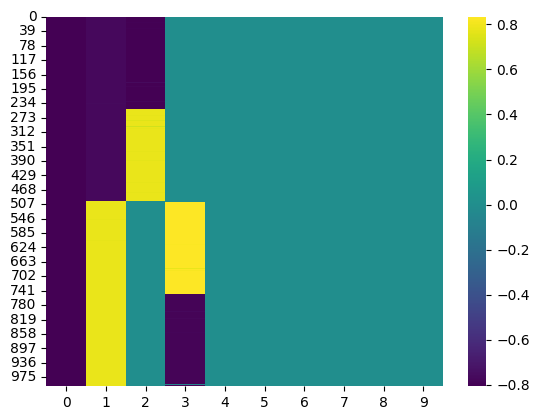

In [38]:
sns.heatmap(mycebmf1.L , cmap="viridis", annot=False)  # set annot=True for numbers
plt.show()